# 39 — Matched Control DiD: Winners vs Non-Winners

## Goal
Compare the career trajectories of **best-paper award winners** against a **matched control group**
of non-winning authors from the same conference and year. This gives us a causal-ish lift estimate:
does winning a best-paper award actually boost your career beyond what a comparable non-winner achieves?

## Design decisions
| Decision | Choice | Rationale |
|----------|--------|-----------|
| Matching unit | `(conference, year)` | Holds venue prestige and field trends fixed |
| Matching variable | Career age at conference year (±2 yrs tolerance) | Controls for seniority |
| Control ratio | **1:5** (up to 5 controls per winner) | Balances statistical power vs API cost |
| Random seed | `42` | Reproducibility |
| Citation metric | Citations received per year (not cumulative) | Same as nb38 — shows the flow of attention |
| Aggregation | Median per relative year × group | Robust to heavy-tailed bibliometric distributions |
| Window | ±5 years, pre-window capped at career age for junior authors | Avoids artificial zeros |

## Lift definition
`lift(t) = median_winner_metric(t) / median_control_metric(t)`
A lift > 1 post-award means winners outperform comparable non-winners *beyond* field/seniority trends.

## Input
`../data/raw/icwsm_jcdl_author_profiles.csv` — built in notebook 36

## Output
- `../data/processed/venue_year_authors.csv` — all authors per (venue, year) from OpenAlex
- `../data/processed/matched_controls.csv` — matched winner→control pairs
- `../data/processed/control_yearly_raw.csv` — per-year counts for control authors
- Plots saved to `../data/processed/`


## 0. Imports & helpers

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OPENALEX_EMAIL = 'sherotowshaw@gmail.com'
HEADERS = {'User-Agent': f'thesis-research mailto:{OPENALEX_EMAIL}'}
BASE = 'https://api.openalex.org'
SLEEP = 0.12
SEED = 42
rng = np.random.default_rng(SEED)

os.makedirs('../data/processed', exist_ok=True)

def oa_get(url, params=None):
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    time.sleep(SLEEP)
    return r.json()


## 1. Resolve OpenAlex source IDs for JCDL and ICWSM

> We query OpenAlex `/sources` by display name to get the canonical source IDs for each venue.
> Using source IDs (rather than fuzzy name matching) ensures we only pull papers from the correct venue.

In [2]:
VENUE_QUERIES = {
    'ICWSM': 'International AAAI Conference on Web and Social Media',
    'JCDL':  'Joint Conference on Digital Libraries',
}

source_ids = {}
for conf, query in VENUE_QUERIES.items():
    data = oa_get(f'{BASE}/sources', params={'search': query, 'per_page': 5})
    results = data.get('results', [])
    if results:
        top = results[0]
        source_ids[conf] = top['id']
        print(f"{conf}: {top['id']}  ({top['display_name']})")
    else:
        print(f'{conf}: NOT FOUND')

print('\nSource IDs resolved:', source_ids)


ICWSM: https://openalex.org/S4387284482  (Proceedings of the International AAAI Conference on Web and Social Media)
JCDL: https://openalex.org/S4306417562  (ACM/IEEE Joint Conference on Digital Libraries)

Source IDs resolved: {'ICWSM': 'https://openalex.org/S4387284482', 'JCDL': 'https://openalex.org/S4306417562'}


## 2. Load winners & deduplicate

> Same dedup rule as nb38: one row per unique author, keeping the earliest award year.

In [3]:
profiles = pd.read_csv('../data/raw/icwsm_jcdl_author_profiles.csv')
profiles = profiles[~profiles['career_age_missing']].copy()

winners = (
    profiles
    .sort_values('award_year')
    .drop_duplicates(subset='author_id', keep='first')
    .reset_index(drop=True)
)

winner_ids = set(winners['author_id'].astype(str))

print(f'Unique winners: {len(winners)}')
print(winners.groupby('conference')['award_year'].agg(['min','max','count']))


Unique winners: 327
             min   max  count
conference                   
ICWSM       2007  2021    123
JCDL        1998  2025    204


## 3. Fetch all authors per (venue, year) from OpenAlex

> For each unique `(conference, year)` in our winner list, we paginate through all works
> published at that venue+year and collect every unique author ID.
>
> **Note:** OpenAlex paginates at 200 results/page. We use cursor-based pagination (`cursor=*`)
> to safely walk through large proceedings. Results are cached to avoid re-fetching.

In [4]:
VENUE_CACHE = '../data/processed/venue_year_authors.csv'

if os.path.exists(VENUE_CACHE):
    venue_authors_df = pd.read_csv(VENUE_CACHE)
    print(f'Loaded from cache: {len(venue_authors_df)} rows')
else:
    records = []
    venue_year_pairs = winners[['conference','award_year']].drop_duplicates().values.tolist()
    print(f'Fetching authors for {len(venue_year_pairs)} (conference, year) pairs...')

    for conf, year in venue_year_pairs:
        src_id = source_ids.get(conf)
        if not src_id:
            print(f'  SKIP {conf} {year} — no source ID')
            continue
        src_short = src_id.split('/')[-1]
        filter_str = f'primary_location.source.id:{src_short},publication_year:{year}'
        cursor = '*'
        page_authors = set()
        while cursor:
            try:
                data = oa_get(f'{BASE}/works', params={
                    'filter': filter_str,
                    'select': 'authorships',
                    'per_page': 200,
                    'cursor': cursor,
                })
            except Exception as e:
                print(f'  ERROR {conf} {year}: {e}')
                break
            for work in data.get('results', []):
                for auth in work.get('authorships', []):
                    aid = auth.get('author', {}).get('id')
                    if aid:
                        page_authors.add(aid)
            cursor = data.get('meta', {}).get('next_cursor')
        for aid in page_authors:
            records.append({'conference': conf, 'year': year, 'author_id': aid})
        print(f'  {conf} {year}: {len(page_authors)} authors')

    venue_authors_df = pd.DataFrame(records)
    venue_authors_df.to_csv(VENUE_CACHE, index=False)
    print(f'Fetched & cached: {len(venue_authors_df)} rows')


Fetching authors for 42 (conference, year) pairs...
  JCDL 1998: 0 authors
  JCDL 1999: 0 authors
  JCDL 2000: 0 authors
  JCDL 2002: 2 authors
  JCDL 2003: 131 authors
  JCDL 2004: 9 authors
  JCDL 2005: 2 authors
  JCDL 2006: 0 authors
  JCDL 2007: 4 authors
  ICWSM 2007: 0 authors
  JCDL 2008: 0 authors
  ICWSM 2008: 0 authors
  JCDL 2009: 0 authors
  ICWSM 2009: 200 authors
  JCDL 2010: 4 authors
  ICWSM 2010: 199 authors
  ICWSM 2011: 0 authors
  JCDL 2011: 2 authors
  ICWSM 2012: 0 authors
  JCDL 2012: 0 authors
  JCDL 2013: 5 authors
  ICWSM 2013: 0 authors
  JCDL 2014: 141 authors
  ICWSM 2014: 241 authors
  JCDL 2015: 0 authors
  ICWSM 2015: 0 authors
  JCDL 2016: 1 authors
  ICWSM 2016: 2 authors
  JCDL 2017: 80 authors
  ICWSM 2017: 396 authors
  ICWSM 2018: 338 authors
  JCDL 2018: 0 authors
  JCDL 2019: 4 authors
  ICWSM 2019: 234 authors
  JCDL 2020: 0 authors
  ICWSM 2020: 337 authors
  ICWSM 2021: 2096 authors
  JCDL 2021: 0 authors
  JCDL 2022: 0 authors
  JCDL 2023: 0

## 4. Build candidate control pool

> Remove anyone already in the winner list from each (venue, year) pool.
> These are our eligible controls — they published at the same venue and year but did not win.

In [5]:
candidates = venue_authors_df[~venue_authors_df['author_id'].isin(winner_ids)].copy()
print(f'Total candidate control rows: {len(candidates)}')
print(candidates.groupby('conference')['author_id'].nunique().rename('unique_candidates'))


Total candidate control rows: 4120
conference
ICWSM    3078
JCDL      336
Name: unique_candidates, dtype: int64


## 5. Fetch career age for candidate controls

> For each unique candidate author we call `/authors/{id}` to get `works_count` and
> `counts_by_year`, from which we derive `first_pub_year` and thus `career_age` at the conference year.
>
> **This is the most API-intensive step** — cached aggressively to `candidate_profiles.csv`.

In [6]:
CAND_PROFILE_CACHE = '../data/processed/candidate_profiles.csv'

unique_candidates = candidates['author_id'].unique()
print(f'Unique candidate authors to profile: {len(unique_candidates)}')

if os.path.exists(CAND_PROFILE_CACHE):
    cand_profiles = pd.read_csv(CAND_PROFILE_CACHE)
    print(f'Loaded from cache: {len(cand_profiles)} rows')
else:
    records = []
    for i, aid in enumerate(unique_candidates):
        short_id = str(aid).split('/')[-1]
        try:
            data = oa_get(f'{BASE}/authors/{short_id}')
        except Exception as e:
            print(f'  ERROR {aid}: {e}')
            continue
        counts = data.get('counts_by_year', [])
        if counts:
            first_pub_year = min(c['year'] for c in counts if c.get('works_count', 0) > 0)
        else:
            first_pub_year = None
        records.append({'author_id': aid, 'first_pub_year': first_pub_year})
        if (i + 1) % 100 == 0:
            print(f'  profiled {i+1}/{len(unique_candidates)}')

    cand_profiles = pd.DataFrame(records)
    cand_profiles.to_csv(CAND_PROFILE_CACHE, index=False)
    print(f'Fetched & cached: {len(cand_profiles)} rows')


Unique candidate authors to profile: 3400
  profiled 100/3400
  profiled 200/3400
  profiled 300/3400
  profiled 400/3400
  profiled 500/3400
  profiled 600/3400
  profiled 700/3400
  profiled 800/3400
  profiled 900/3400
  profiled 1000/3400
  profiled 1100/3400
  profiled 1200/3400
  profiled 1300/3400
  profiled 1400/3400
  profiled 1500/3400
  profiled 1600/3400
  profiled 1700/3400
  profiled 1800/3400
  profiled 1900/3400
  profiled 2000/3400
  profiled 2100/3400
  profiled 2200/3400
  profiled 2300/3400
  profiled 2400/3400
  profiled 2500/3400
  profiled 2600/3400
  profiled 2700/3400
  profiled 2800/3400
  profiled 2900/3400
  profiled 3000/3400
  profiled 3100/3400
  profiled 3200/3400
  profiled 3300/3400
  profiled 3400/3400
Fetched & cached: 3400 rows


## 6. Match winners to controls (career age ±2 years, up to 5 per winner)

> For each winner we:
> 1. Look at candidates from the same `(conference, year)`
> 2. Compute `career_age_at_conf = conf_year − first_pub_year` for each candidate
> 3. Keep candidates within ±2 years of the winner's career age
> 4. Randomly sample up to 5 (seed=42)
>
> Winners with fewer than 1 matched control are flagged and excluded from the analysis.

In [7]:
CAREER_AGE_TOL = 2
MAX_CONTROLS = 5

# Merge candidate author_id → first_pub_year
cands_merged = candidates.merge(cand_profiles, on='author_id', how='left')
cands_merged = cands_merged.dropna(subset=['first_pub_year']).copy()
cands_merged['first_pub_year'] = cands_merged['first_pub_year'].astype(int)
cands_merged['career_age_at_conf'] = cands_merged['year'] - cands_merged['first_pub_year']
# Remove candidates with implausible career ages
cands_merged = cands_merged[cands_merged['career_age_at_conf'] >= 0]

matched_rows = []
unmatched = []

for _, winner_row in winners.iterrows():
    w_id   = winner_row['author_id']
    w_conf = winner_row['conference']
    w_year = winner_row['award_year']
    w_age  = winner_row['career_age']

    pool = cands_merged[
        (cands_merged['conference'] == w_conf) &
        (cands_merged['year']       == w_year) &
        (abs(cands_merged['career_age_at_conf'] - w_age) <= CAREER_AGE_TOL)
    ]

    if pool.empty:
        unmatched.append(w_id)
        continue

    sampled = pool.sample(n=min(MAX_CONTROLS, len(pool)), random_state=SEED)
    for _, ctrl_row in sampled.iterrows():
        matched_rows.append({
            'winner_id'          : w_id,
            'winner_conference'  : w_conf,
            'winner_award_year'  : w_year,
            'winner_career_age'  : w_age,
            'winner_is_junior'   : winner_row['is_junior'],
            'control_id'         : ctrl_row['author_id'],
            'control_career_age' : ctrl_row['career_age_at_conf'],
        })

matched_df = pd.DataFrame(matched_rows)
matched_df.to_csv('../data/processed/matched_controls.csv', index=False)

print(f'Matched pairs:         {len(matched_df)}')
print(f'Winners matched:        {matched_df["winner_id"].nunique()}')
print(f'Winners unmatched:      {len(unmatched)}')
print(f'Unique control authors: {matched_df["control_id"].nunique()}')
print()
print(matched_df.groupby('winner_conference')['control_id'].count().rename('control_rows'))


Matched pairs:         571
Winners matched:        134
Winners unmatched:      193
Unique control authors: 396

winner_conference
ICWSM    429
JCDL     142
Name: control_rows, dtype: int64


## 7. Fetch yearly trajectories for control authors

> Same approach as nb38 — pull `counts_by_year` from OpenAlex for each unique control author.
> Cached to `control_yearly_raw.csv`.

In [8]:
CTRL_CACHE = '../data/processed/control_yearly_raw.csv'

unique_controls = matched_df['control_id'].unique()
print(f'Unique control authors to fetch: {len(unique_controls)}')

if os.path.exists(CTRL_CACHE):
    ctrl_yearly = pd.read_csv(CTRL_CACHE)
    print(f'Loaded from cache: {len(ctrl_yearly)} rows')
else:
    records = []
    for i, aid in enumerate(unique_controls):
        short_id = str(aid).split('/')[-1]
        try:
            data = oa_get(f'{BASE}/authors/{short_id}')
        except Exception as e:
            print(f'  ERROR {aid}: {e}')
            continue
        for entry in data.get('counts_by_year', []):
            records.append({
                'author_id'     : aid,
                'year'          : entry['year'],
                'works_count'   : entry.get('works_count', 0),
                'cited_by_count': entry.get('cited_by_count', 0),
            })
        if (i + 1) % 100 == 0:
            print(f'  fetched {i+1}/{len(unique_controls)}')

    ctrl_yearly = pd.DataFrame(records)
    ctrl_yearly.to_csv(CTRL_CACHE, index=False)
    print(f'Fetched & cached: {len(ctrl_yearly)} rows')


Unique control authors to fetch: 396
  fetched 100/396
  fetched 200/396
  fetched 300/396
Fetched & cached: 7483 rows


## 8. Build relative-year trajectories for controls

> We align each control author to the *winner's* award year (the reference event), not their own.
> This is the correct DiD alignment — both groups share the same t=0.

In [9]:
MAX_WINDOW = 5

ctrl_merged = ctrl_yearly.merge(
    matched_df[['control_id','winner_award_year','winner_career_age',
                'winner_conference','winner_is_junior','control_career_age']].rename(
        columns={'control_id': 'author_id'}),
    on='author_id', how='inner'
)

ctrl_merged['relative_year'] = ctrl_merged['year'] - ctrl_merged['winner_award_year']

ctrl_merged = ctrl_merged[
    (ctrl_merged['relative_year'] <= MAX_WINDOW) &
    (ctrl_merged['relative_year'] >= -ctrl_merged['control_career_age'].clip(upper=MAX_WINDOW))
].copy()

ctrl_merged['group']     = 'Control'
ctrl_merged['seniority'] = ctrl_merged['winner_is_junior'].map({True: 'Junior (<5 yr)', False: 'Senior (≥5 yr)'})
ctrl_merged['conference']= ctrl_merged['winner_conference']

print(f'Control trajectory rows: {len(ctrl_merged)}')


Control trajectory rows: 4755


## 9. Load winner trajectories from nb38 & tag group

> Reuse the winner trajectories already computed in nb38 so we don't re-fetch.

In [10]:
winner_traj = pd.read_csv('../data/processed/author_yearly_trajectories.csv')
winner_traj['group'] = 'Winner'

# Align column names to match ctrl_merged
winner_traj = winner_traj.rename(columns={'award_year': 'winner_award_year'})

print(f'Winner trajectory rows: {len(winner_traj)}')


Winner trajectory rows: 2653


## 10. Combine & plot helper

> Stack winner and control trajectories into one DataFrame, then define a reusable plot function.

In [11]:
COMMON_COLS = ['author_id','relative_year','works_count','cited_by_count',
               'group','conference','seniority','winner_award_year']

combined = pd.concat([
    winner_traj[COMMON_COLS],
    ctrl_merged[COMMON_COLS],
], ignore_index=True)

COLORS = {'Winner': "#1B1B1B", 'Control': "#8D8D8D"}

def did_plot(df, title, savepath):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for metric, ax, ylabel, panel_title in [
        ('works_count',    axes[0], 'Median publications per year',     'Publications per year'),
        ('cited_by_count', axes[1], 'Median citations received per year','Citations received per year'),
    ]:
        for group, grp_df in df.groupby('group'):
            agg = (grp_df.groupby('relative_year')[metric]
                        .median().reset_index().sort_values('relative_year'))
            ax.plot(agg['relative_year'], agg[metric],
                    marker='o', markersize=5,
                    color=COLORS.get(group, 'gray'), label=group)
        ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Award year (t=0)')
        ax.set_xlabel('Years relative to award year')
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title)
        ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {savepath}')


## 11. Overall DiD — Winners vs Controls (all venues)

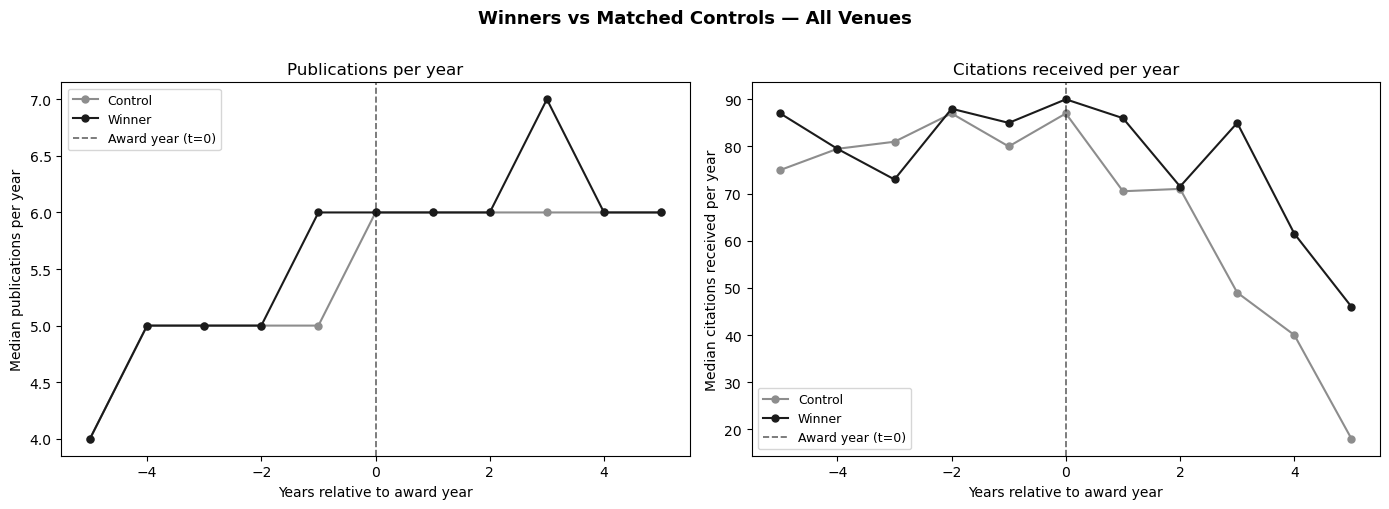

Saved → ../data/processed/did_matched_overall.png


In [12]:
did_plot(combined, 'Winners vs Matched Controls — All Venues',
         '../data/processed/did_matched_overall.png')


## 12. Split by Conference (ICWSM vs JCDL)

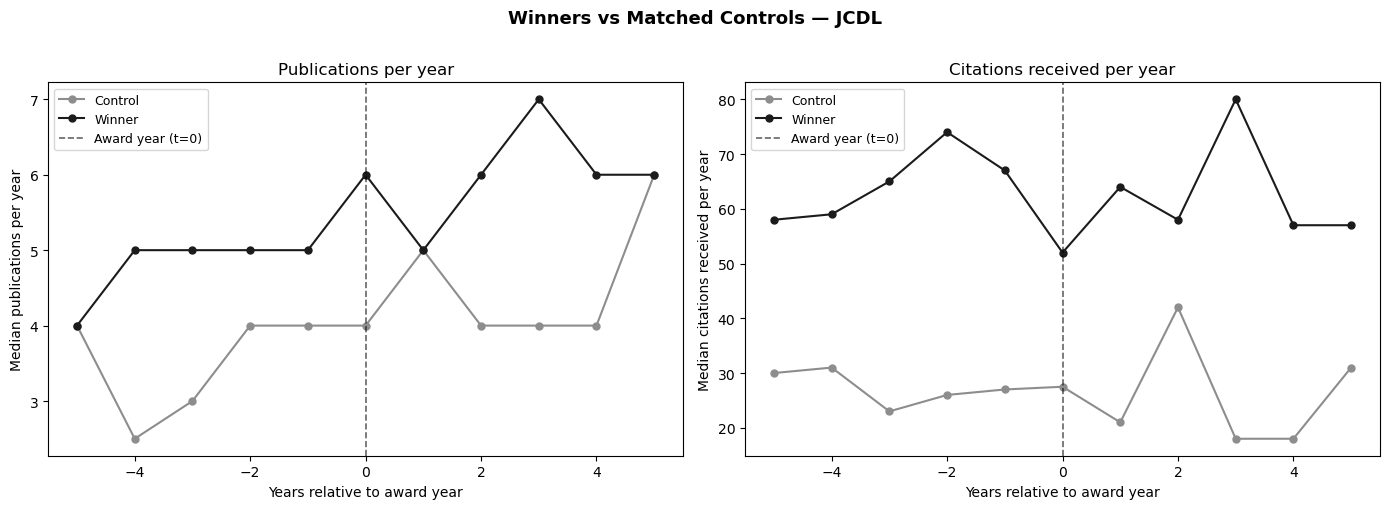

Saved → ../data/processed/did_matched_jcdl.png


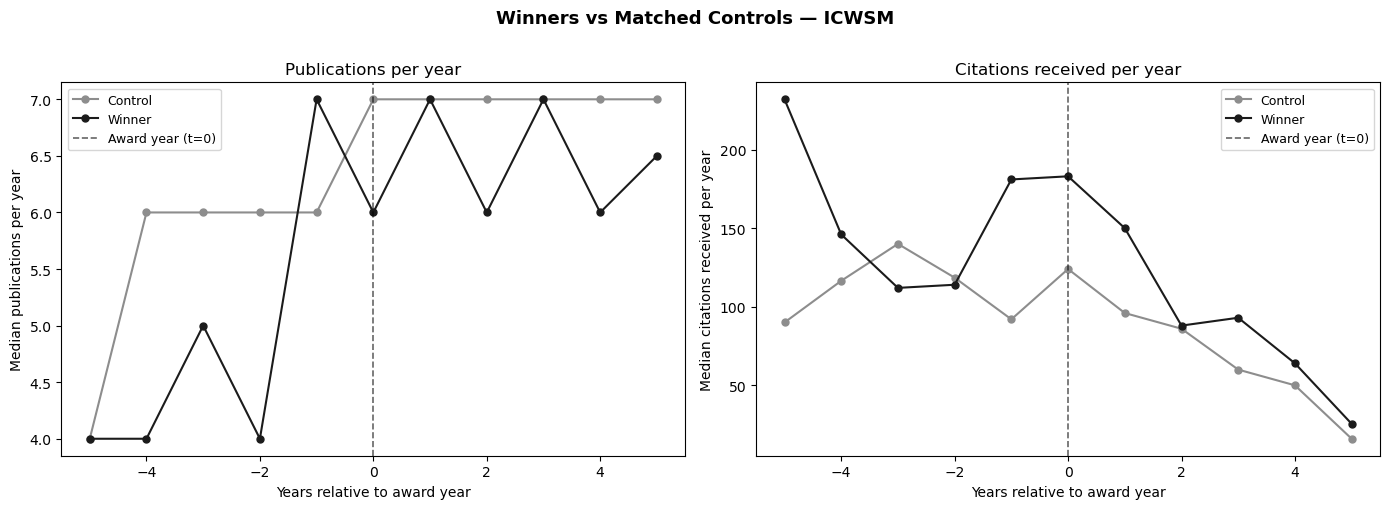

Saved → ../data/processed/did_matched_icwsm.png


In [13]:
for conf in combined['conference'].unique():
    subset = combined[combined['conference'] == conf]
    did_plot(subset, f'Winners vs Matched Controls — {conf}',
             f'../data/processed/did_matched_{conf.lower()}.png')


## 13. Lift table

> `lift(t) = median_winner / median_control` at each relative year.
> Values > 1 mean winners outperform controls; < 1 means controls outperform winners.
>
> Shown separately for each conference and for citations (the key outcome metric).

In [14]:
def lift_table(df, metric='cited_by_count'):
    winner_med = (df[df['group']=='Winner']
                   .groupby('relative_year')[metric].median().rename('winner'))
    ctrl_med   = (df[df['group']=='Control']
                   .groupby('relative_year')[metric].median().rename('control'))
    tbl = pd.concat([winner_med, ctrl_med], axis=1).dropna()
    tbl['lift'] = (tbl['winner'] / tbl['control']).round(3)
    return tbl

print('=== CITATIONS LIFT — All Venues ===')
display(lift_table(combined))

for conf in ['ICWSM', 'JCDL']:
    print(f'\n=== CITATIONS LIFT — {conf} ===')
    subset = combined[combined['conference'] == conf]
    display(lift_table(subset))


=== CITATIONS LIFT — All Venues ===


,winner,control,lift
relative_year,,,
-5,87.0,75.0,1.160
-4,79.5,79.5,1.000
-3,73.0,81.0,0.901
-2,88.0,87.0,1.011
-1,85.0,80.0,1.062
0,90.0,87.0,1.034
1,86.0,70.5,1.220
2,71.5,71.0,1.007
3,85.0,49.0,1.735



=== CITATIONS LIFT — ICWSM ===


,winner,control,lift
relative_year,,,
-5,232.0,90.0,2.578
-4,146.0,116.5,1.253
-3,112.0,140.0,0.800
-2,114.0,118.5,0.962
-1,181.0,92.0,1.967
0,183.0,124.0,1.476
1,150.0,96.0,1.562
2,88.0,86.0,1.023
3,93.0,60.0,1.550



=== CITATIONS LIFT — JCDL ===


,winner,control,lift
relative_year,,,
-5,58.0,30.0,1.933
-4,59.0,31.0,1.903
-3,65.0,23.0,2.826
-2,74.0,26.0,2.846
-1,67.0,27.0,2.481
0,52.0,27.5,1.891
1,64.0,21.0,3.048
2,58.0,42.0,1.381
3,80.0,18.0,4.444


## 14. Coverage summary

> How many unique authors contribute at each relative year in each group.
> Critical for interpreting noisy tails — if n < 20, treat medians with caution.

In [15]:
coverage = (combined
    .groupby(['group','relative_year'])['author_id']
    .nunique()
    .unstack('group')
    .sort_index()
)
print('Authors contributing per relative year:')
display(coverage)


Authors contributing per relative year:


group,Control,Winner
relative_year,,
-5,262,188
-4,283,216
-3,286,227
-2,307,251
-1,317,264
0,396,320
1,321,271
2,304,252
3,296,233
